# I. Sprint 1 - Préparation des données 

##### Livrable 1 - Groupe 4 : AIT RAZOUK Ilyass, IZEM Mohammed Amine, BOIVIN Pierre, WYART Nathan

## Contexte

Le diabète fait partie des maladies chroniques les plus courantes aux États-Unis et touche chaque année des millions de personnes. Cette affection sérieuse se traduit par une mauvaise régulation du sucre dans le sang, ce qui peut, à long terme, réduire la qualité de vie et même l’espérance de vie. Au moment de la digestion, les aliments se transforment en sucres qui passent dans le sang. Cela incite le pancréas à produire de l’insuline, une hormone qui permet aux cellules d’utiliser ces sucres comme source d’énergie. Dans le cas du diabète, soit l’organisme ne produit pas assez d’insuline, soit il réagit mal.

L’excès prolongé de sucre dans le sang augmente les risques de complications graves : maladies cardiovasculaires, perte de la vue, amputations ou encore insuffisance rénale. Même si le diabète ne se guérit pas, il est possible d’en limiter les effets grâce à la perte de poids, à une alimentation adaptée, à une activité physique régulière et à un suivi médical approprié. Plus le diagnostic est posé tôt, plus il est possible d’agir efficacement. C’est pour cette raison que les outils de prédiction du risque de diabète représentent un enjeu important de santé publique.

L’ampleur du phénomène est frappante. Selon les Centres pour le contrôle et la prévention des maladies (CDC) en 2018, 34,2 millions d’Américains vivaient avec un diabète, et 88 millions étaient prédiabétiques. Une personne diabétique sur cinq n’en avait pas conscience, et la grande majorité des personnes prédiabétiques ignorait également leur situation. Le diabète de type 2, la forme la plus fréquente, est influencé par de nombreux facteurs : âge, niveau d’études, revenus, zone géographique, origine ethnique ou encore conditions sociales de vie. Les populations les plus défavorisées sont souvent les plus touchées.

La maladie représente aussi un poids financier immense : le coût du diabète diagnostiqué est estimé à environ 327 milliards de dollars par an, et si l’on inclut le diabète non diagnostiqué et le prédiabète, on approche les 400 milliards de dollars.

## Présentation du jeu de données

Le Système de surveillance des facteurs de risque comportementaux (BRFSS) est une enquête téléphonique annuelle menée par les Centres pour le contrôle et la prévention des maladies (CDC) sur la santé. Chaque année, cette enquête recueille les réponses de plus de 400 000 Américains sur leurs comportements à risque pour la santé, leurs maladies chroniques et leur recours aux services de prévention. Elle est réalisée chaque année depuis 1984. Pour ce projet, nous avons utilisé un fichier CSV des données disponibles sur Kaggle pour l'année 2015. Ce jeu de données contient les réponses de 253 680 personnes et comporte 22 variables. Ces variables correspondent soit à des questions posées directement aux participants, soit à des variables calculées à partir de leurs réponses individuelles.

Les variables du dataset sont :

- Diabetes_binary(0 = no diabetes 1 = prediabetes  2 = diabetes)

- HighBP(0 = no high BP 1 = high BP)

- HighChol(0 = no high cholesterol 1 = high cholesterol)

- CholCheck(0 = no cholesterol check in 5 years 1 = yes cholesterol check in 5 years)

- BMI(Body Mass Index)

- Smoker(Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes] 0 = no 1 = yes)

- Stroke((Ever told) you had a stroke. 0 = no 1 = yes)

- HeartDiseaseorAttack(coronary heart disease (CHD) or myocardial infarction (MI) 0 = no 1 = yes)

- PhysActivity(physical activity in past 30 days - not including job 0 = no 1 = yes)

- Fruits(Consume Fruit 1 or more times per day 0 = no 1 = yes)

- Veggies(Consume Vegetables 1 or more times per day 0 = no 1 = yes)

- HvyAlcoholConsump((adult men >=14 drinks per week and adult women>=7 drinks per week) 0 = no 1 = yes)

- AnyHealthcare(Have any kind of health care coverage, including health insurance, prepaid plans such as HMO, etc. 0 = no 1 = yes)

- NoDocbcCost(Was there a time in the past 12 months when you needed to see a doctor but could not because of cost? 0 = no 1 = yes)

- GenHlth(Would you say that in general your health is: scale 1-5 1 = excellent 2 = very good 3 = good 4 = fair 5 = poor)

- MentHlth(days of poor mental health scale 1-30 days)

- PhysHlth(physical illness or injury days in past 30 days scale 1-30)

- DiffWalk(Do you have serious difficulty walking or climbing stairs? 0 = no 1 = yes)

- Sex(0 = female 1 = male)

- Age(13-level age category (_AGEG5YR see codebook) 1 = 18-24 9 = 60-64 13 = 80 or older)

- Education(Education level (EDUCA see codebook) scale 1-6 1 = Never attended school or only kindergarten 2 =)

- Income(Income scale (INCOME2 see codebook) scale 1-8 1 = less than $10,000 5 = less than $35,000 8 = $75,000 or more)

## Importations des librairies

Ici, nous importons les bibliothèques nécessaires pour manipuler des données, les visualiser et préparer un modèle de machine learning.

Nous utilisons : 
- pandas et numpy : Traitement des données
- matplotlib et seaborn : Visualisation
- train_test_split : Séparer les données en ensembles d’entraînement et de test
- StandardScaler : Normaliser les variables

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

## Chargement du Dataset et Typage des variables

Ici, nous chargeons notre Dataset (fichier .csv) contenant les données dans un DataFrame df à l’aide de pandas.

Ensuite, nous affichons les premières lignes du dataset avec df.head() afin de visualiser rapidement sa structure et vérifier que les données ont bien été importées.

In [2]:
df = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")

df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## Analyse et typage des variables

Nous utilisons df.shape pour obtenir les dimensions du DataFrame df.

Cela nous permet de connaître le nombre de lignes et de colonnes du dataset.

In [3]:
df.shape

(253680, 22)

Nous utilisons aussi df.info() pour afficher un résumé du DataFrame df.

Cela nous donne des informations sur les colonnes (noms, types de données), le nombre de valeurs non nulles et l’utilisation mémoire, ce qui permet de mieux comprendre la structure et vérifier la qualité des données.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

df.describe() nous permet d'obtenir des statistiques descriptives du DataFrame df.

Cela nous donne un résumé des variables numériques : moyenne, écart-type, valeurs minimales et maximales, ainsi que les quartiles (25%, 50%, 75%), afin de mieux comprendre la distribution des données.

In [5]:
df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


## Nettoyage des données

#### Gestion des valeurs nulls

Ici, nous utilisons df.isnull().sum() pour vérifier les valeurs manquantes dans le DataFrame df.

Cette commande compte le nombre de valeurs nulles pour chaque colonne, ce qui nous permet d’identifier rapidement si des données sont manquantes et dans quelles variables.

In [6]:
df.isnull().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

#### Gestion des valeurs dupliquées

Ici, nous utilisons df.duplicated().sum() pour détecter les lignes dupliquées dans le DataFrame df.

Cette commande compte le nombre de lignes identiques présentes plusieurs fois, ce qui nous permet d’identifier d’éventuels doublons à nettoyer dans les données.

In [7]:
df.duplicated().sum()

np.int64(24206)

Comme il existe des lignes dupliquées, nous les supprimons du DataFrame df à l’aide de df.drop_duplicates().

Cela permet de nettoyer les données en ne conservant qu’une seule occurrence de chaque ligne identique.

In [8]:
df = df.drop_duplicates()

## Séparation de la variable cible et des variables explicatives

Nous séparons les données en variables explicatives et en variable cible.

- X contient toutes les colonnes sauf "Diabetes_binary", qui servent de features (entrées du modèle).
- y contient la colonne "Diabetes_binary", qui est la cible que nous cherchons à prédire.

In [9]:
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

## Analyse Exploratoire qualitative / quantitative

Ici, nous affichons les distributions des variables du DataFrame df sous forme d’histogrammes avec df.hist().

Le paramètre figsize=(15,12) permet de définir la taille globale des graphiques, et plt.show() sert à afficher les figures. Cela nous aide à visualiser la distribution de chaque variable.

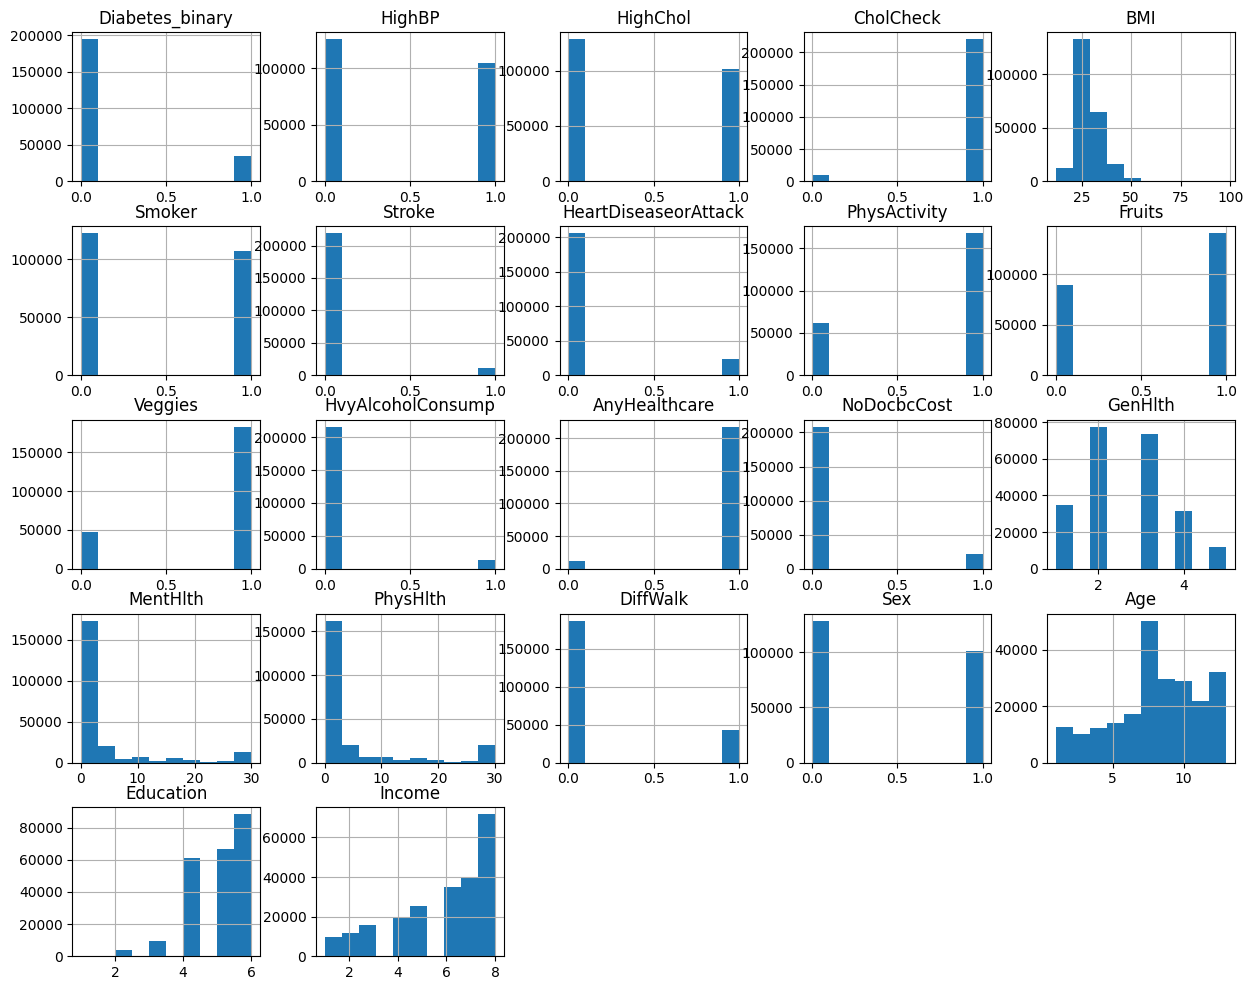

In [10]:
df.hist(figsize=(15,12))
plt.show()

Nous affichons les histogrammes des colonnes 'BMI', 'MentHlth' et 'PhysHlth' du DataFrame df.

Le paramètre figsize=(15, 5) ajuste la taille des graphiques pour mieux les visualiser côte à côte, et plt.show() permet d’afficher les histogrammes.

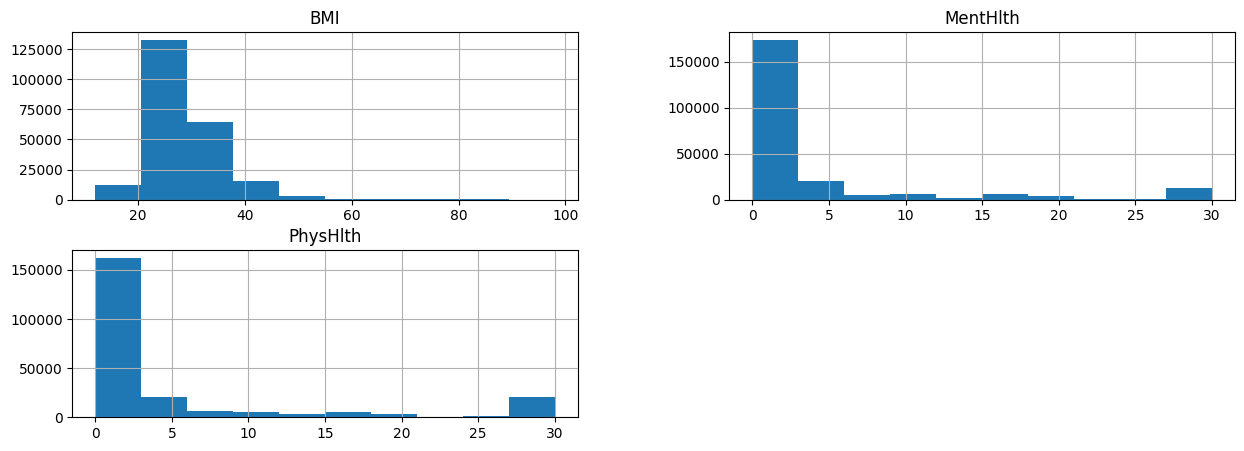

In [11]:
cols = ['BMI', 'MentHlth', 'PhysHlth']
df[cols].hist(figsize=(15, 5)) # figsize adapté pour 3 graphiques
plt.show()

Nous analysons les corrélations entre les variables du dataset pour identifier les meilleurs prédicteurs et supprimer les doublons :
1. On calcule d’abord la matrice de corrélation avec df.corr().
2. Ensuite, on affiche une heatmap avec seaborn pour visualiser les relations entre toutes les colonnes. L'objectif est d'identifier la colinéarité : si deux variables explicatives sont trop corrélées entre elles, on en supprime une pour alléger le modèle et éviter le bruit.
3. Puis, on isole les corrélations avec la variable cible "Diabetes_binary" et nous les trions.
4. Enfin, on représente ces corrélations sous forme de barplot pour identifier les variables les plus fortement liées à la cible. Ce seront les indices les plus importants pour notre réseau de neurones.

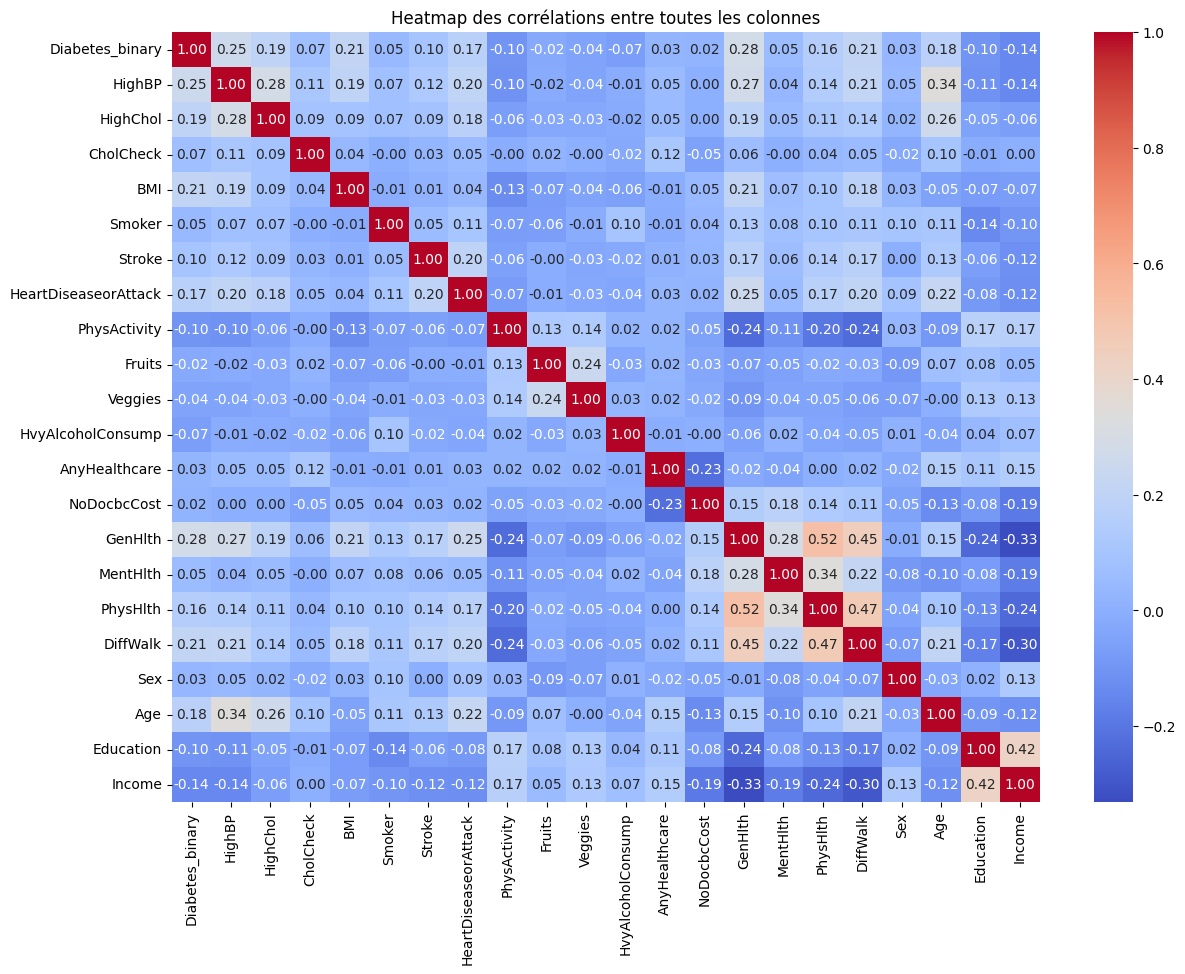

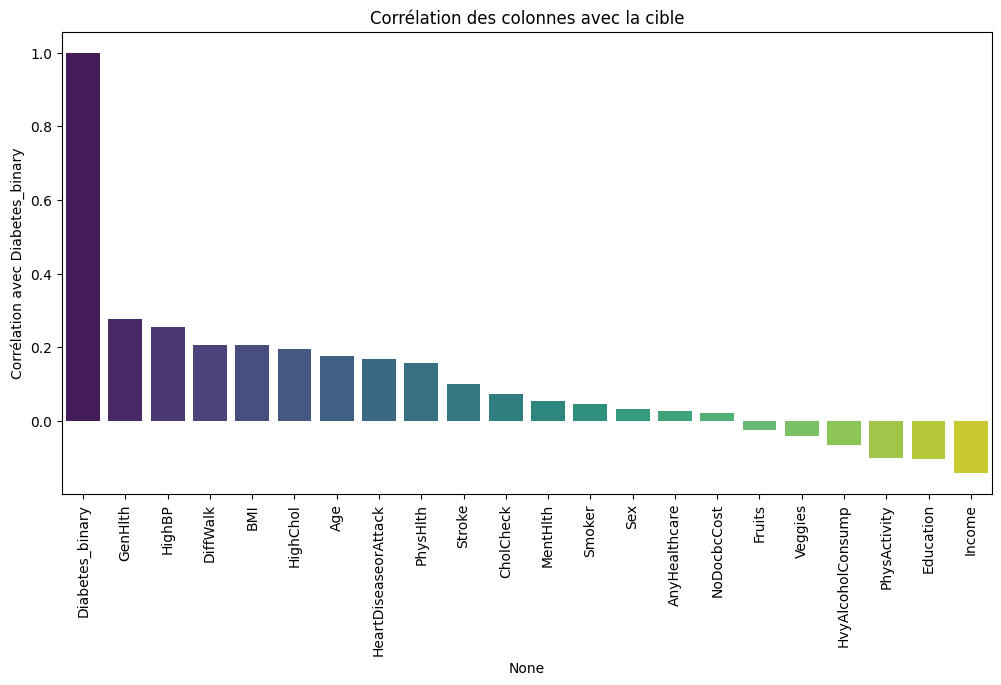

In [12]:
corr_matrix = df.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap des corrélations entre toutes les colonnes")
plt.show()

corr_with_target = corr_matrix['Diabetes_binary'].sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    x=corr_with_target.index, 
    y=corr_with_target.values, 
    hue=corr_with_target.index,  
    palette="viridis", 
    legend=False               
)
plt.xticks(rotation=90)
plt.ylabel("Corrélation avec Diabetes_binary")
plt.title("Corrélation des colonnes avec la cible")
plt.show()

Ici, nous extrayons les corrélations entre chaque variable et la cible "Diabetes_binary" à partir de la matrice de corrélation.

Nous les trions ensuite par ordre décroissant avec sort_values(ascending=False) afin d’identifier les variables les plus fortement corrélées à la cible.

In [13]:
corr_target = corr_matrix["Diabetes_binary"].sort_values(ascending=False)

corr_target

Diabetes_binary         1.000000
GenHlth                 0.276940
HighBP                  0.254318
DiffWalk                0.205302
BMI                     0.205086
HighChol                0.194944
Age                     0.177263
HeartDiseaseorAttack    0.168213
PhysHlth                0.156211
Stroke                  0.099193
CholCheck               0.072523
MentHlth                0.054153
Smoker                  0.045504
Sex                     0.032724
AnyHealthcare           0.025331
NoDocbcCost             0.020048
Fruits                 -0.024805
Veggies                -0.041734
HvyAlcoholConsump      -0.065950
PhysActivity           -0.100404
Education              -0.102686
Income                 -0.140659
Name: Diabetes_binary, dtype: float64

Ici, nous affichons des boîtes à moustaches (boxplots) pour toutes les variables du DataFrame df.

Cela nous permet de visualiser la distribution des données, ainsi que les valeurs aberrantes (outliers). Le figsize ajuste la taille du graphique, xticks(rotation=90) permet de mieux lire les noms des variables, et plt.show() affiche le tout.

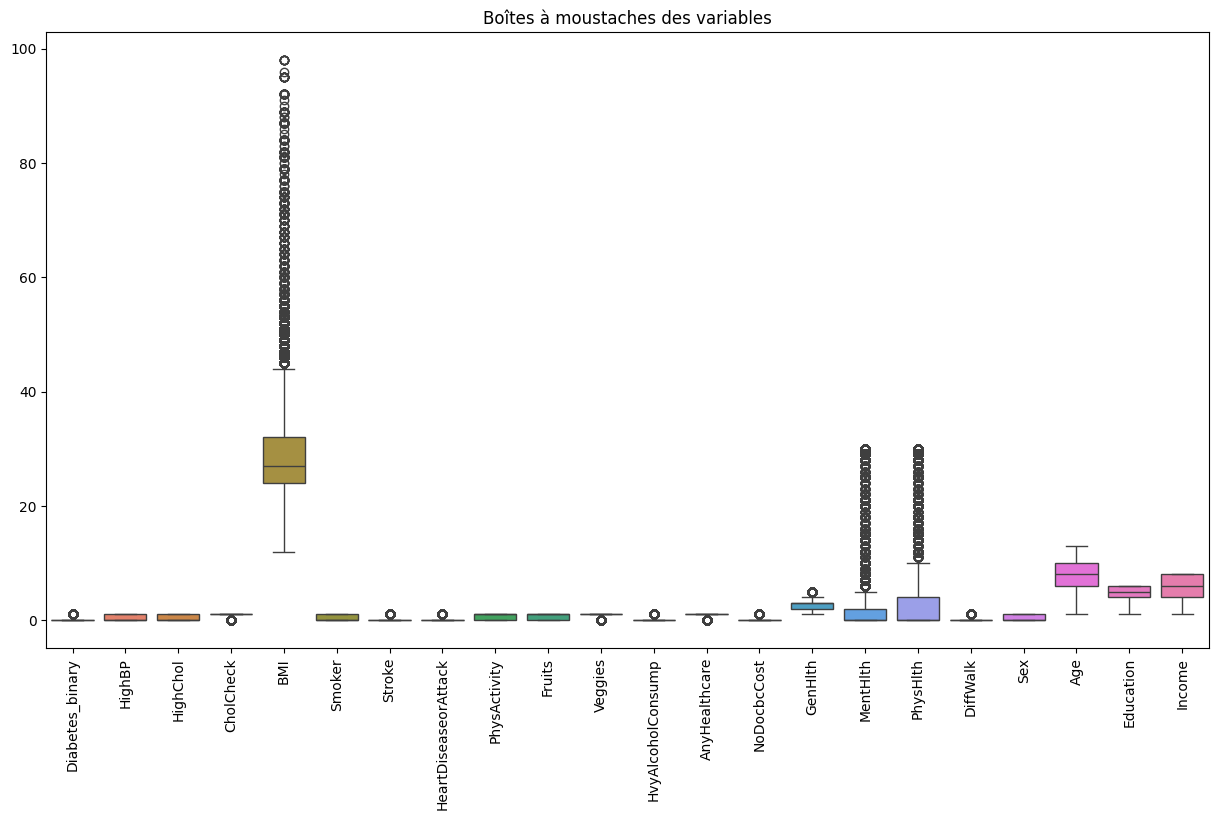

In [14]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title("Boîtes à moustaches des variables")

plt.show()

Nous affichons un boxplot pour comparer la distribution du BMI en fonction de la variable "Diabetes_binary".

Cela nous permet d’observer comment le BMI varie selon les personnes diabétiques ou non, et de repérer d’éventuelles différences de distribution entre les deux groupes.

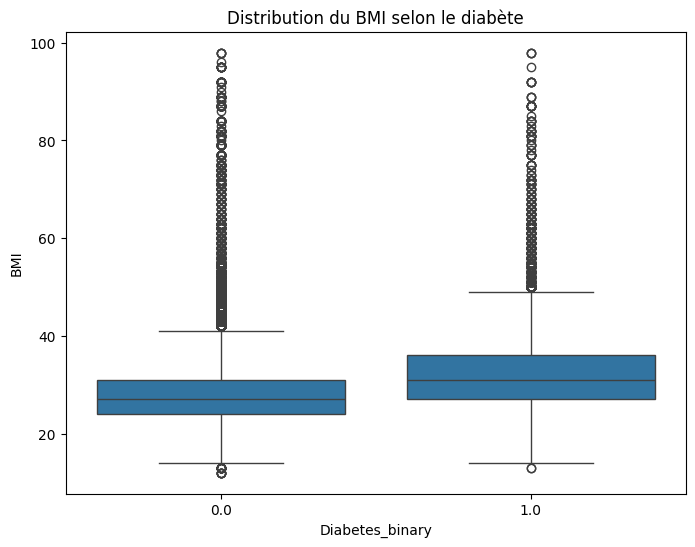

In [15]:
plt.figure(figsize=(8,6))

sns.boxplot(x="Diabetes_binary", y="BMI", data=df)

plt.title("Distribution du BMI selon le diabète")

plt.show()

Nous affichons un countplot pour visualiser la distribution de la variable "Diabetes_binary".

Cela nous permet de voir le nombre d’observations dans chaque classe (diabétique vs non diabétique) et d’identifier un éventuel déséquilibre entre les classes.

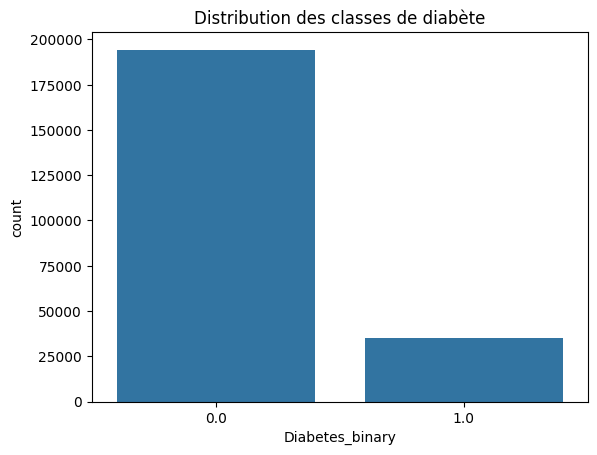

In [16]:
sns.countplot(x="Diabetes_binary", data=df)

plt.title("Distribution des classes de diabète")

plt.show()

## Scission Train / Test / Validation

Ici, nous divisons les données en ensembles d’entraînement et temporaire.

Nous utilisons train_test_split pour séparer X et y :

70 % des données sont utilisées pour l’entraînement (X_train, y_train)
30 % sont mises de côté dans X_temp et y_temp pour une future séparation (validation/test)

Le paramètre random_state=42 permet de rendre la séparation reproductible.

In [17]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Ensuite, nous divisons l’ensemble temporaire en deux parties : validation et test.

Nous utilisons train_test_split sur X_temp et y_temp :

50 % deviennent les données de validation (X_val, y_val)
50 % deviennent les données de test (X_test, y_test)

In [18]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

Enfin, nous standardisons les variables explicatives pour mettre toutes les features sur la même échelle.

Nous créons un StandardScaler, puis nous l’ajustons et transformons les données d’entraînement avec fit_transform
nous transformons les données de validation et de test avec transform uniquement (en utilisant les paramètres appris sur le train)

Cela permet d’éviter toute fuite d’information et d’assurer une bonne généralisation du modèle.

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

## Feature Ingineering

Ici, nous appliquons SMOTE pour gérer le déséquilibre des classes dans les données d’entraînement.

Nous créons un objet SMOTE, puis nous utilisons fit_resample sur X_train et y_train pour générer de nouvelles observations synthétiques de la classe minoritaire
obtenir un jeu d’entraînement équilibré (X_train_res, y_train_res)

In [20]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
# =========================================================
#  AVANT : SMOTE (SUPPRIMÉ)
# =========================================================
# smote = SMOTE(random_state=42)
# X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# PROBLÈME :
# - données artificielles
# - surapprentissage observé
# - moins réaliste


# =========================================================
#  APRÈS : CLASS WEIGHT (AJOUTÉ)
# =========================================================

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, class_weights))

print(" Class weights :", class_weights)

# AVANTAGE :
# ✔ pas de données artificielles
# ✔ meilleur généralisation
# ✔ corrige déséquilibre naturellement

 Class weights : {np.float64(0.0): np.float64(0.5900041872663028), np.float64(1.0): np.float64(3.2776485471759713)}


Nous affichons à nouveau les histogrammes de toutes les variables du DataFrame df avec df.hist().

Le paramètre figsize=(15,12) ajuste la taille des graphiques pour une meilleure lisibilité, et plt.show() permet de les afficher.

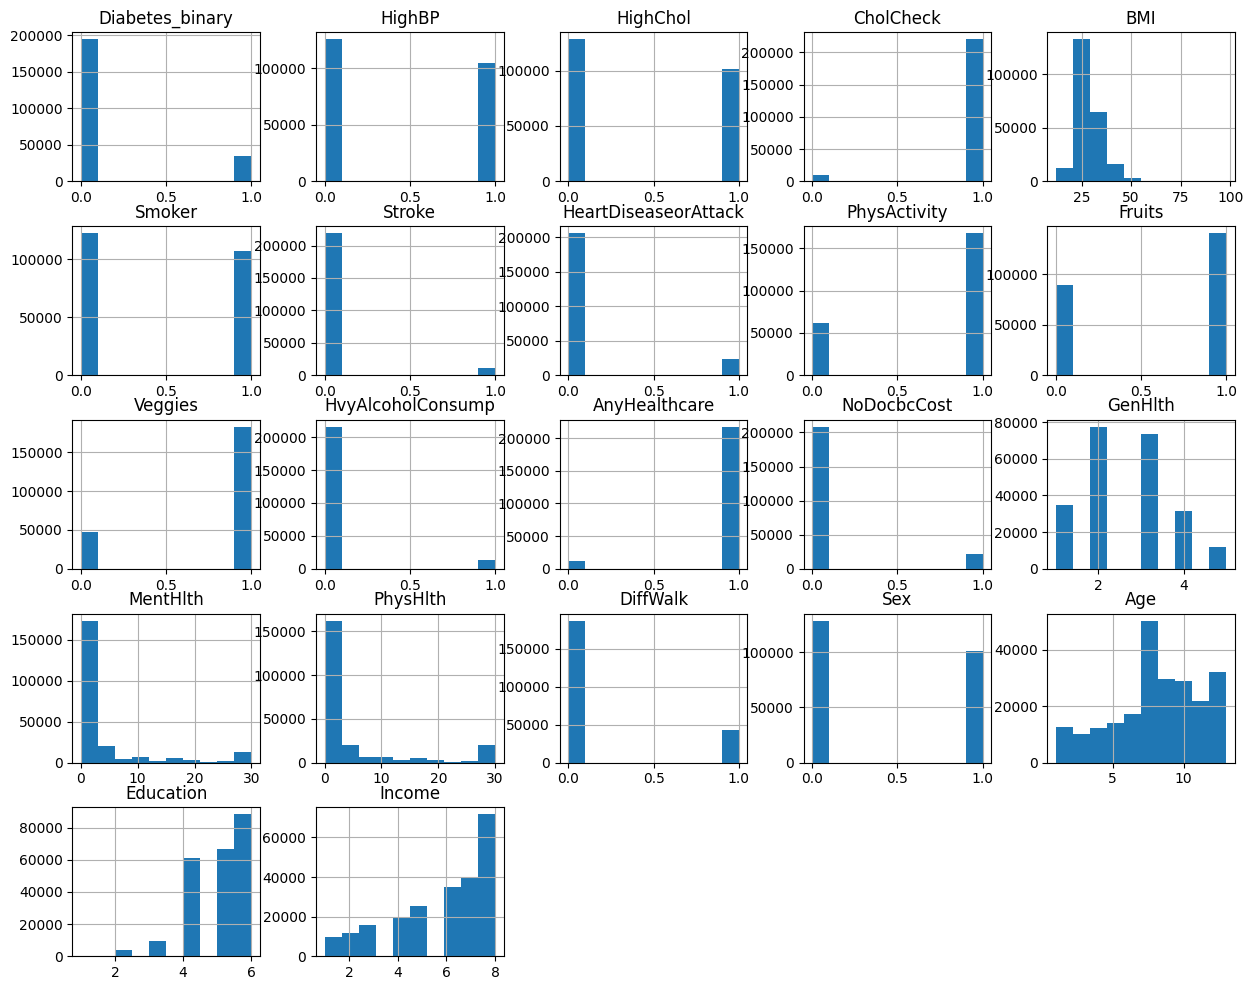

In [21]:
df.hist(figsize=(15,12))
plt.show()

## Sauvegarde du Dataset nettoyé

Une fois toutes ces étapes effectuées, nous sauvegardons le DataFrame df dans un fichier CSV nommé "diabetes_clean.csv".

Le paramètre index=False permet de ne pas inclure l’index du DataFrame dans le fichier exporté, afin d’obtenir un fichier plus propre.

In [22]:
df.to_csv("diabetes_clean.csv", index=False)

## Sauvegarde des objets du Pipeline

Enfin, on sauvegarde l’objet scaler entraîné dans un fichier avec joblib.

La fonction joblib.dump() permet de sérialiser le scaler et de l’enregistrer sous le nom "scaler.pkl", afin de pouvoir le recharger et l’utiliser plus tard sans avoir à le réentraîner.

In [23]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

## Conclusion Sprint 1

Dans ce premier livrable, nous avons préparé et exploré le dataset en vue d’une future modélisation.

Nous avons commencé par charger et analyser les données (structure, statistiques, valeurs manquantes, doublons), puis nous avons effectué un nettoyage en supprimant les duplications.

Ensuite, nous avons exploré les données visuellement (histogrammes, boxplots, corrélations) afin de mieux comprendre leur distribution et leur lien avec la variable cible "Diabetes_binary".

Nous avons également réalisé un prétraitement des données en normalisant certaines variables et en séparant le dataset en ensembles d’entraînement, de validation et de test. Enfin, nous avons pris en compte le déséquilibre des classes grâce à class weights, et sauvegardé les données et le scaler pour une utilisation future.

En résumé, nous avons construit une base de données propre, analysée et prête à être utilisée pour entraîner des modèles de machine learning dans les prochains livrables.

## Sprint 2 - Développement, Comparaison et Optimisation du Modèle Deep Learning

Dans cette seconde phase, nous abordons la conception technique de notre intelligence artificielle. L'objectif est de mettre en compétition différentes architectures de réseaux de neurones (simple, profond, régularisé) afin d'identifier la plus apte à dépister le diabète. Cette analyse comparative s'appuiera sur des indicateurs visuels précis (courbes d'apprentissage, matrices de confusion, courbes ROC) et des métriques adaptées aux exigences médicales, notamment la maximisation du taux de détection (Recall). Enfin, nous proposerons un modèle final optimisé, alliant performances de santé et efficacité énergétique grâce à l'évaluation de sa consommation de ressources.


RÉSULTATS POUR LE MODÈLE : SIMPLE (Seuil 0.5)
 Temps total : 37.89 sec
 Epochs fixes : 20
 Consommation : 100% (pas d'early stopping)


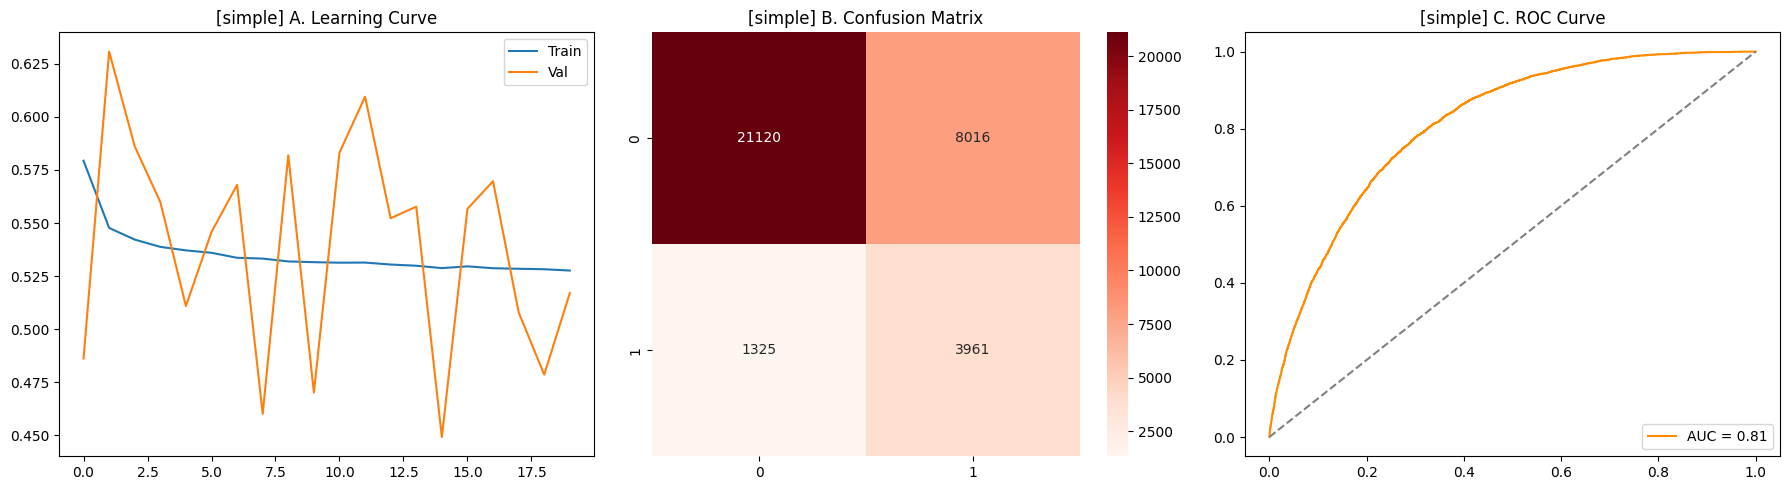


--- Rapport de classification (simple) ---
              precision    recall  f1-score   support

         0.0       0.94      0.72      0.82     29136
         1.0       0.33      0.75      0.46      5286

    accuracy                           0.73     34422
   macro avg       0.64      0.74      0.64     34422
weighted avg       0.85      0.73      0.76     34422


RÉSULTATS POUR LE MODÈLE : PROFOND (Seuil 0.5)
 Temps total : 40.61 sec
 Epochs fixes : 20
 Consommation : 100% (pas d'early stopping)


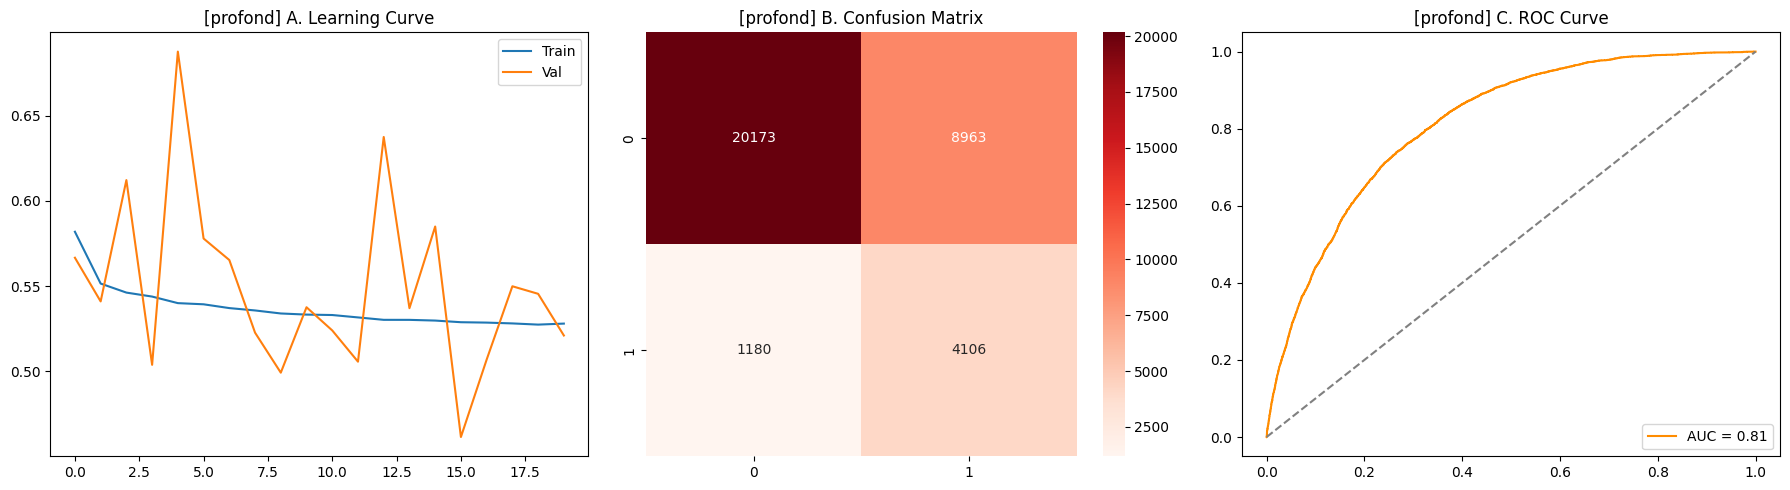


--- Rapport de classification (profond) ---
              precision    recall  f1-score   support

         0.0       0.94      0.69      0.80     29136
         1.0       0.31      0.78      0.45      5286

    accuracy                           0.71     34422
   macro avg       0.63      0.73      0.62     34422
weighted avg       0.85      0.71      0.75     34422


RÉSULTATS POUR LE MODÈLE : REGULARISE (Seuil 0.5)
 Temps total : 42.06 sec
 Epochs fixes : 20
 Consommation : 100% (pas d'early stopping)


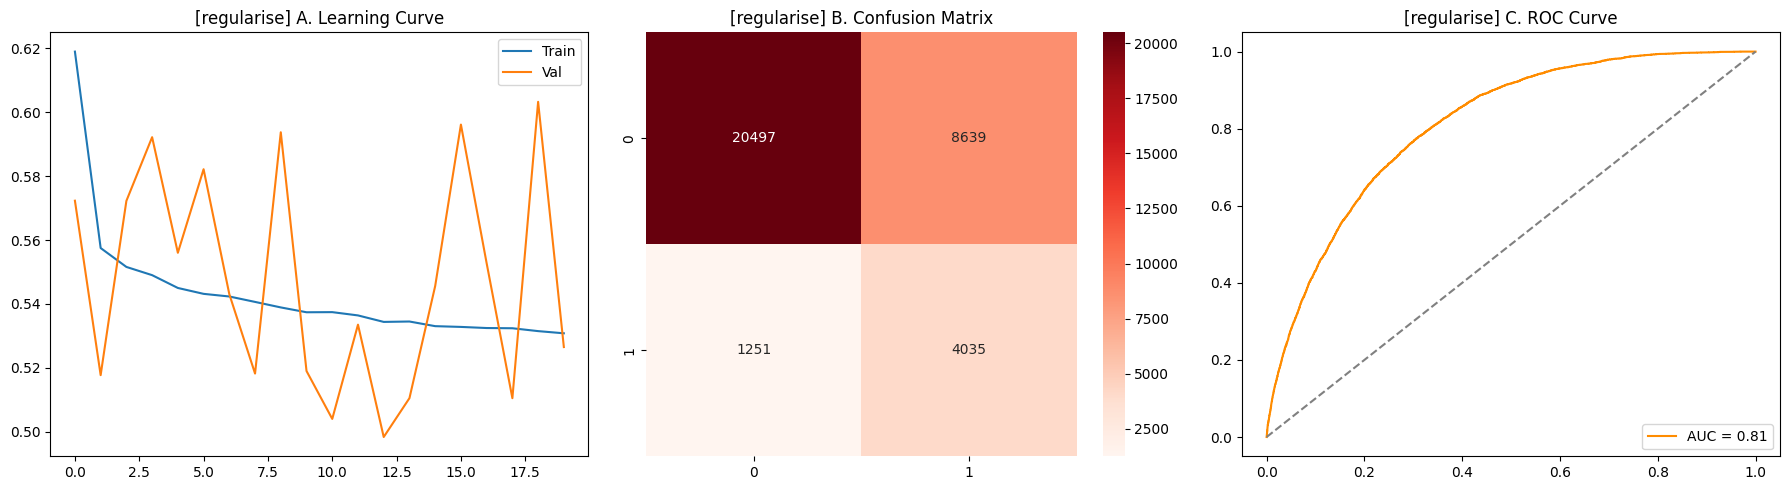


--- Rapport de classification (regularise) ---
              precision    recall  f1-score   support

         0.0       0.94      0.70      0.81     29136
         1.0       0.32      0.76      0.45      5286

    accuracy                           0.71     34422
   macro avg       0.63      0.73      0.63     34422
weighted avg       0.85      0.71      0.75     34422



In [24]:
import time
import numpy as np

# =========================================================
#  DONNÉES (IMPORTANT)
# =========================================================
#  AVANT : X_train_res (SMOTE utilisé)
#  PROBLÈME : données artificielles → overfitting

# =========================================================
#  APRÈS : données réelles + class_weight
# =========================================================
# X_train, y_train utilisés
# class_weights appliqués dans fit()


# =========================================================
#  1. FONCTION DE CRÉATION DU MODÈLE
# =========================================================

def build_model(type_archi="simple"):

    model = Sequential()

    # =========================
    # INPUT
    # =========================
    model.add(Input(shape=(X_train.shape[1],)))

    # =========================
    # ARCHITECTURE DE BASE
    # =========================
    model.add(Dense(32, activation='relu'))
    # ➜ base commune à tous les modèles

    # =====================================================
    #  VARIATIONS D'ARCHITECTURE
    # =====================================================

    if type_archi == "profond":

        #  VERSION PROFONDE (AJOUTÉE)
        model.add(Dense(64, activation='relu'))
        model.add(Dense(32, activation='relu'))

        #  AVANT : pas de régularisation
        #  AMÉLIORATION POSSIBLE (option)
        model.add(Dropout(0.3))  # AJOUT anti-overfitting

    elif type_archi == "regularise":

        #  VERSION RÉGULARISÉE (AMÉLIORÉE)
        model.add(Dense(32, activation='relu'))
        model.add(Dropout(0.3))  # ➜ AJOUT : réduction overfitting

    # =========================
    # OUTPUT
    # =========================
    model.add(Dense(1, activation='sigmoid'))

    # =========================
    # OPTIMISATEUR
    # =========================
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


# =========================================================
#  2. EXPÉRIMENTATION DES ARCHITECTURES
# =========================================================

architectures = ["simple", "profond", "regularise"]
max_epochs = 20

for archi in architectures:

    print("\n" + "="*60)
    print(f"RÉSULTATS POUR LE MODÈLE : {archi.upper()} (Seuil 0.5)")
    print("="*60)

    model = build_model(archi)

    # =========================
    #  ENTRAÎNEMENT
    # =========================
    debut = time.time()

    history = model.fit(
        X_train, y_train,              #  MODIFIÉ : suppression SMOTE
        epochs=max_epochs,
        batch_size=64,
        validation_split=0.2,
        class_weight=class_weights,    #  AJOUT IMPORTANT
        verbose=0
    )

    temps_total = time.time() - debut


    # =====================================================
    #  BILAN
    # =====================================================

    print(f" Temps total : {temps_total:.2f} sec")
    print(f" Epochs fixes : {max_epochs}")
    print(f" Consommation : 100% (pas d'early stopping)")

    # =====================================================
    #  PRÉDICTIONS
    # =====================================================

    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)


    # =====================================================
    #  VISUALISATION
    # =====================================================

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # =========================
    # LOSS CURVE
    # =========================
    axes[0].plot(history.history['loss'], label='Train')
    axes[0].plot(history.history['val_loss'], label='Val')
    axes[0].set_title(f'[{archi}] A. Learning Curve')
    axes[0].legend()

    # =========================
    # CONFUSION MATRIX
    # =========================
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[1])
    axes[1].set_title(f'[{archi}] B. Confusion Matrix')

    # =========================
    # ROC CURVE
    # =========================
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    axes[2].plot(fpr, tpr, color='darkorange', label=f'AUC = {roc_auc:.2f}')
    axes[2].plot([0, 1], [0, 1], '--', color='gray')
    axes[2].set_title(f'[{archi}] C. ROC Curve')
    axes[2].legend(loc="lower right")

    plt.tight_layout()
    plt.show()


    # =====================================================
    #  RAPPORT FINAL
    # =====================================================

    print(f"\n--- Rapport de classification ({archi}) ---")
    print(classification_report(y_test, y_pred))

On peut observer que les modèles Simple et Profond sont très similaires. Ils excellent dans la détection des malades avec un excellent Recall (79 % pour le simple, 78 % pour le profond). En contrepartie, ils génèrent beaucoup de "fausses alertes" chez les patients sains, ce qui fait baisser leur exactitude globale (autour de 69-70 %).

De son côté le modèle Régularisé semble globalement meilleur au premier abord (Exactitude de 75 % et meilleur F1-score). Cependant, ce gain se fait au détriment de la détection des malades : son Recall chute à 70 %.

Dans un contexte médical de dépistage du diabète, la priorité absolue est de minimiser les Faux Négatifs (les malades renvoyés chez eux par erreur). Le modèle Simple est celui qui rattrape le plus de malades (79 % de Recall). Il est préférable d'avoir une précision faible (31 %, donc prescrire des examens de contrôle inutiles à des patients sains) plutôt que de rater près de 30 % des diabétiques comme le ferait le modèle régularisé.

Nous avons alors décidés de garder le modèle simple, cependant nous allons modifier ses paramètres afin d'améliorer sa performances et d'avoir de meilleurs résultats.

Pour transformer le modèle simple en une architecture optimisée, cinq paramètres clés ont été intégrés :

1. La profondeur (Couches à 64 et 32 neurones) : L'ajout de couches supplémentaires permet au réseau d'extraire des schémas plus complexes et subtils dans les données des patients.

2. La Normalisation par lot (Batch Normalization) : Cette technique recentre mathématiquement les informations entre chaque couche. Elle stabilise le modèle et évite que certains neurones ne saturent.

3. Le Dropout (0.3) : Il désactive aléatoirement 30 % des neurones à chaque étape de l'entraînement. Cela empêche le réseau de mémoriser les données par cœur (surapprentissage) et le force à être performant sur des données inédites.

4. Le Taux d'apprentissage (Learning Rate à 0.0005) : En diminuant la vitesse d'apprentissage de l'optimiseur Adam, on force l'algorithme à avancer à "petits pas", ce qui lui permet de trouver un réglage de précision bien plus fin.

5. Le Seuil de décision (0.3) : Externe à l'architecture mais vital pour l'évaluation médicale, il permet de classer un patient comme "Diabétique" dès 30 % de probabilité, maximisant ainsi le repêchage des malades (Recall).

[codecarbon WARNING @ 11:29:26] Multiple instances of codecarbon are allowed to run at the same time.



ENTRAÎNEMENT DU MODÈLE OPTIMISÉ (ANTI-OVERFITTING)
Entraînement en cours...
Epoch 12: early stopping
Restoring model weights from the end of the best epoch: 5.

BILAN ÉNERGÉTIQUE ET PERFORMANCE
 Temps total : 38.59 sec
 Epochs utilisées : 12 / 80
 Économie epochs : 68
 Conso énergie : 0.000218 kWh


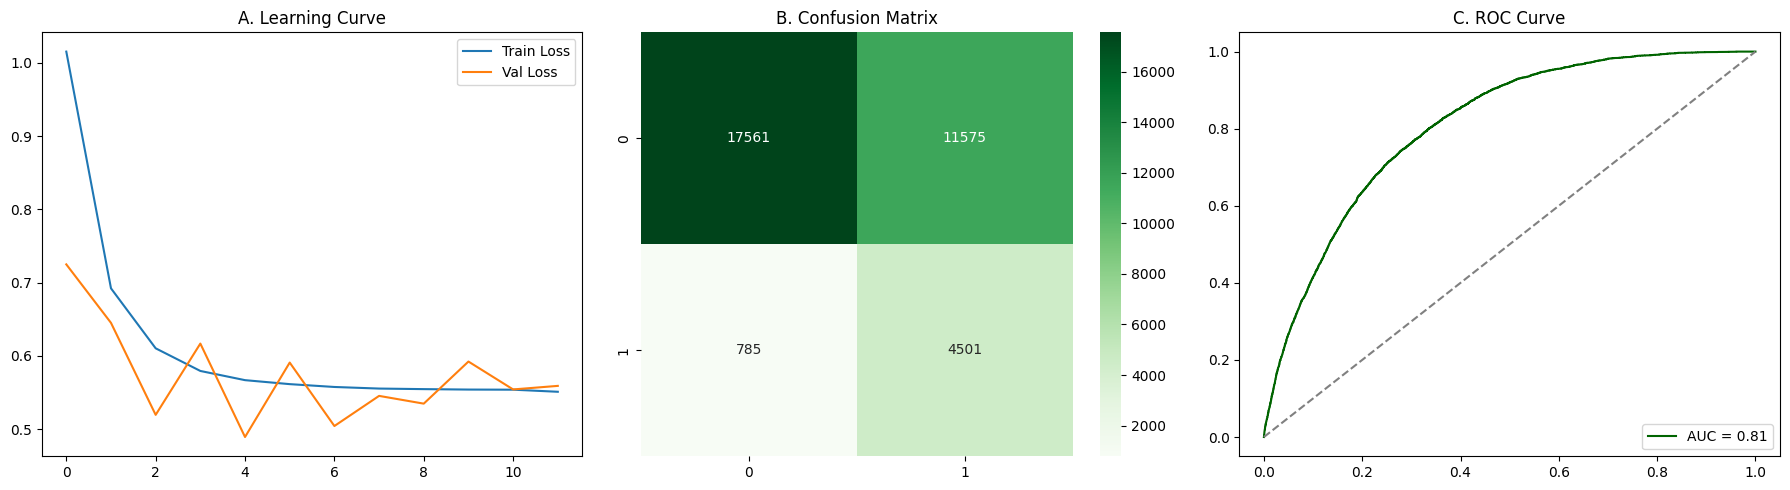


--- Classification Report ---
              precision    recall  f1-score   support

         0.0       0.96      0.60      0.74     29136
         1.0       0.28      0.85      0.42      5286

    accuracy                           0.64     34422
   macro avg       0.62      0.73      0.58     34422
weighted avg       0.85      0.64      0.69     34422



In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from codecarbon import EmissionsTracker


# =========================================================
#  MODÈLE ORIGINAL (AVANT)
# =========================================================
# - Dense(64)
# - Dense(32)
# - Dropout 0.3
#  PROBLÈME : overfitting + pas de régularisation


# =========================================================
#  MODÈLE AMÉLIORÉ (VERSION ACTUELLE)
# =========================================================

def build_model_optimise():

    model = Sequential()

    # =========================
    # INPUT
    # =========================
    model.add(Input(shape=(X_train.shape[1],)))

    # =========================
    # COUCHE 1 (MODIFIÉE)
    # =========================
    model.add(Dense(64, activation='relu', kernel_regularizer='l2'))
    # ➜ AJOUT : L2 regularization
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    # ➜ MODIFIÉ : 0.3 → 0.4

    # =========================
    # COUCHE 2 (MODIFIÉE)
    # =========================
    model.add(Dense(32, activation='relu', kernel_regularizer='l2'))
    # ➜ AJOUT : L2 regularization
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    # =========================
    # COUCHE 3 (AJOUTÉE)
    # =========================
    model.add(Dense(16, activation='relu'))
    model.add(Dropout(0.3))

    # =========================
    # OUTPUT
    # =========================
    model.add(Dense(1, activation='sigmoid'))

    # =========================
    # OPTIMISATEUR (MODIFIÉ)
    # =========================
    optimizer = Adam(learning_rate=0.0003)
    # ➜ MODIFIÉ : learning rate réduit

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model




print("\n" + "="*60)
print("ENTRAÎNEMENT DU MODÈLE OPTIMISÉ (ANTI-OVERFITTING)")
print("="*60)

model_opt = build_model_optimise()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

print("Entraînement en cours...")

debut_entrainement = time.time()

tracker = EmissionsTracker(project_name="Modele_Diabete_Optimise", log_level="error")
tracker.start()

history_opt = model_opt.fit(
    X_train, y_train,               
    epochs=80,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights,     
    callbacks=[early_stop],         
    verbose=0
)

emissions = tracker.stop()
energie_kwh = tracker.final_emissions_data.energy_consumed

fin_entrainement = time.time()
temps_total = fin_entrainement - debut_entrainement



epochs_reels = len(history_opt.history['loss'])
economie_epochs = 80 - epochs_reels

print("\n" + "="*60)
print("BILAN ÉNERGÉTIQUE ET PERFORMANCE")
print("="*60)

print(f" Temps total : {temps_total:.2f} sec")
print(f" Epochs utilisées : {epochs_reels} / 80")
print(f" Économie epochs : {economie_epochs}")
print(f" Conso énergie : {energie_kwh:.6f} kWh")




y_pred_prob = model_opt.predict(X_test, verbose=0)

y_pred = (y_pred_prob > 0.35).astype(int)




fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# LOSS
axes[0].plot(history_opt.history['loss'], label='Train Loss')
axes[0].plot(history_opt.history['val_loss'], label='Val Loss')
axes[0].set_title("A. Learning Curve")
axes[0].legend()

# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("B. Confusion Matrix")

# ROC CURVE
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[2].plot(fpr, tpr, color='darkgreen', label=f"AUC = {auc(fpr,tpr):.2f}")
axes[2].plot([0,1],[0,1],'--', color='gray')
axes[2].set_title("C. ROC Curve")
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()




print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


ENTRAÎNEMENT DU MODÈLE OPTIMISÉ
Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 11.

 Temps : 63.30937099456787
 Énergie : 0.0004098245696322531 kWh


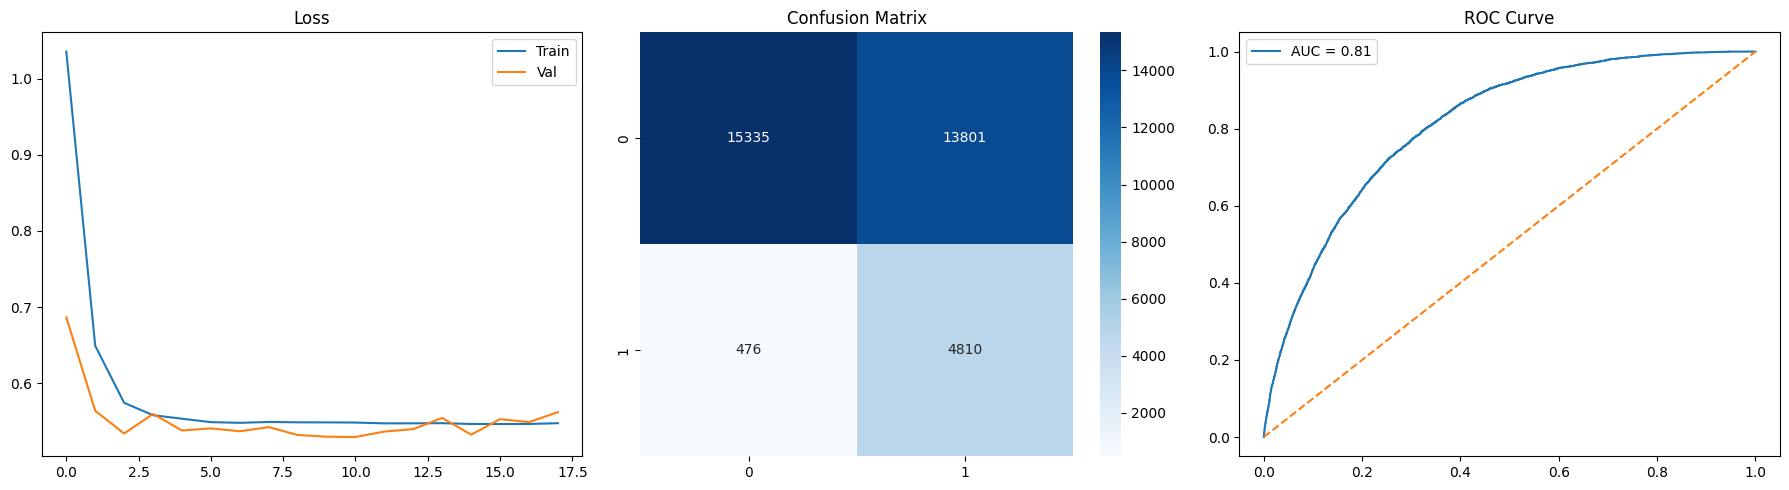


--- Rapport de classification ---
              precision    recall  f1-score   support

         0.0       0.97      0.53      0.68     29136
         1.0       0.26      0.91      0.40      5286

    accuracy                           0.59     34422
   macro avg       0.61      0.72      0.54     34422
weighted avg       0.86      0.59      0.64     34422



In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

from codecarbon import EmissionsTracker





def build_model_optimise():

    model = Sequential()

    model.add(Input(shape=(X_train.shape[1],)))

    model.add(Dense(64, activation='relu', kernel_regularizer='l2'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(Dense(32, activation='relu', kernel_regularizer='l2'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(Dense(16, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=0.0003)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model



print("\n" + "="*60)
print("ENTRAÎNEMENT DU MODÈLE OPTIMISÉ")
print("="*60)

model_opt = build_model_optimise()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

tracker = EmissionsTracker(project_name="Modele_Diabete_Final", log_level="error")
tracker.start()

debut = time.time()

history_opt = model_opt.fit(
    X_train_scaled, y_train,
    epochs=80,
    batch_size=64,
    validation_data=(X_val_scaled, y_val),
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=0
)

emissions = tracker.stop()
energie_kwh = tracker.final_emissions_data.energy_consumed

fin = time.time()

print("\n Temps :", fin - debut)
print(" Énergie :", energie_kwh, "kWh")



y_pred_prob = model_opt.predict(X_test_scaled, verbose=0)
y_pred = (y_pred_prob > 0.35).astype(int)



fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_opt.history['loss'], label='Train')
axes[0].plot(history_opt.history['val_loss'], label='Val')
axes[0].set_title("Loss")
axes[0].legend()

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[2].plot(fpr, tpr, label=f"AUC = {auc(fpr,tpr):.2f}")
axes[2].plot([0,1],[0,1],'--')
axes[2].set_title("ROC Curve")
axes[2].legend()

plt.tight_layout()
plt.show()



print("\n--- Rapport de classification ---")
print(classification_report(y_test, y_pred))




## Conclusion Sprint 2

Le modèle développé est un réseau de neurones dense construit avec TensorFlow/Keras, conçu pour un problème de classification binaire. Les données ont été standardisées à l’aide de StandardScaler, puis le modèle a été entraîné avec des techniques de régularisation (Dropout, L2, BatchNormalization) afin de limiter le surapprentissage. Un mécanisme d’early stopping a également été utilisé pour arrêter l’entraînement au moment optimal.

Après entraînement, le modèle a été évalué sur un jeu de test indépendant. Les résultats montrent une capacité de discrimination correcte avec une AUC de 0.81, ce qui indique que le modèle distingue globalement bien les deux classes.

Cependant, l’analyse détaillée met en évidence un déséquilibre dans les performances :

La classe positive (1) est très bien détectée avec un rappel élevé de 0.90, ce qui signifie que le modèle identifie la majorité des cas positifs.
En revanche, la précision est faible (0.26), ce qui indique un grand nombre de faux positifs.
La classe négative (0) est moins bien reconnue, avec un rappel de 0.53.

La matrice de confusion confirme cette tendance, montrant que le modèle a tendance à prédire trop souvent la classe positive.

En conclusion, le modèle est efficace pour le dépistage des cas positifs (bonne sensibilité), mais manque de précision. Il est donc adapté à une utilisation de type “screening”, mais nécessite des ajustements (notamment du seuil de décision ou du traitement du déséquilibre des classes) pour améliorer sa fiabilité globale.